In [1]:
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data.dataloader import DataLoader
import sys
sys.path.append("C:/Users/tjsss/OneDrive/Desktop/machine learning/mlFromScratch")
import torchvision
from torchvision import transforms
from utils.utilities import add_to_class, HyperParameters

In [2]:
kaggle_api=os.getenv('KAGGLE_API_TOKEN')
if not kaggle_api:
    raise ValueError("API token not found! Check your .env file.")

print(f"Token successfully loaded!")

Token successfully loaded!


## load mnist dataset

In [3]:
class FashionMNIST():
    def __init__(self, path):
        self.root = path
        self.trans = transforms.Compose([transforms.Resize(32), 
                                         transforms.ToTensor()])
        self.train = torchvision.datasets.FashionMNIST(root = self.root, train = True, transform=self.trans, download=True)
        self.val = torchvision.datasets.FashionMNIST(root=self.root, train = False, transform=self.trans, download=True)
        


In [4]:
path = 'C:/Users/tjsss/OneDrive/Desktop/machine learning/mlFromScratch/fashionMNISTdataset'
data = FashionMNIST(path = path)

In [5]:
@add_to_class(FashionMNIST)
def text_labels(self, indices):
    labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
              'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    
    return [labels[int(i)] for i in indices]

In [6]:
@add_to_class(FashionMNIST)
def get_data(self, train, batch_size = 16):
    self.batch_size = batch_size
    data = self.train if train else self.val
    return DataLoader(data, self.batch_size , shuffle=train)


In [7]:
x,y = next(iter(data.get_data(True)))
print(x.shape, y.shape, x.dtype, y.dtype)

torch.Size([16, 1, 32, 32]) torch.Size([16]) torch.float32 torch.int64


In [8]:
@add_to_class(FashionMNIST)
def show_images(self, imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        try:
            img = img.numpy()
        except:
            pass
        ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles and i < len(titles):
            ax.set_title(titles[i])
    plt.tight_layout()
    return axes

@add_to_class(FashionMNIST)
def visualize(self, batch, nrows=1, ncols=8, labels=[]):
    """Visualize a batch of data."""
    x, y = batch
    if not labels:
        labels = self.text_labels(y)
    # Notice 'titles=labels' instead of '[labels]' to avoid nesting lists
    self.show_images(x.squeeze(1), nrows, ncols, titles=labels)


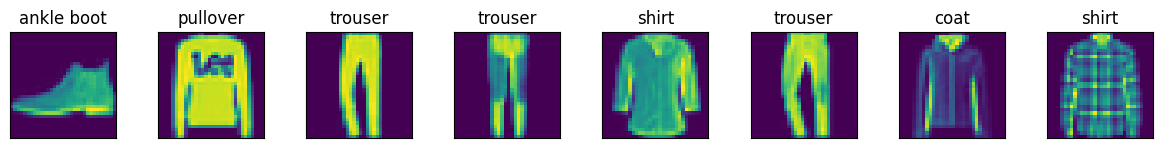

In [9]:
batch = next(iter(data.get_data(train=False)))
data.visualize(batch = batch)

In [10]:
batch[:-1][0][15].size()


torch.Size([1, 32, 32])

In [11]:
class CrossEntropyLoss(nn.Module):
    def __init__(self):
        super().__init__()
        
    def forward(self,logits, y):
        y_exp = torch.exp(logits)
        prob = y_exp / torch.sum(y_exp, dim =1, keepdim = True)
        
        batch_size = y_exp.size(0)
        row_indices = torch.arange(batch_size)
        
        true_class_prob = prob[row_indices, y]
        loss = -torch.log(true_class_prob + 1e-15)
        return loss.mean()

In [24]:
from utils.gradientDescent import SGD

class Classifier(nn.Module):
    
    def __init__(self, input_dims ,n_classes):
        super().__init__()
        self.n_classes = n_classes
        self.linear = nn.Linear(input_dims*input_dims ,self.n_classes)
        self.bias = self.linear.bias
        self.weight = self.linear.weight

        self.criterion = CrossEntropyLoss()

    def configure_optim(self, ):
        return SGD([self.weight , self.bias], lr = 0.01)
    @torch.enable_grad()        
    def calc(self, x):
        x = x.view(x.size(0) , -1)
        return self.linear(x)
        
    @torch.enable_grad()
    def loss_fn(self,x, y):
        logits = self.calc(x)
        return self.criterion.forward(logits, y) 
    def accuracy(self, logits , y):
        predictions = torch.argmax(logits, dim = 1)
        return (predictions == y).float().mean()
    @torch.enable_grad()
    def train(self, train_loader, val_loader, epochs):
        optim = self.configure_optim()
        self.loss_mean_store = []
        self.val_loss_mean_store  =[]
        
        
        for epoch in range(epochs):
            
            mean_train_loss = 0.0
            running_loss = 0.0
            num_train_batches = 0
            print('-'*10 , epoch+1, '-'*10)
            
            for x_batch, y_batch in train_loader:
                optim.zero_grad()
                loss = self.loss_fn(x_batch, y_batch.squeeze(-1).long())
                loss.backward()
                optim.step()
                running_loss += loss.item()
                self.loss_mean_store.append(loss.item())
                num_train_batches += 1
            
            mean_train_loss = running_loss / num_train_batches
            
            
            ## VALIDATION LOSS
            running_val_loss = 0.0
            num_val_batches = 0
            
            with torch.no_grad(): # Ensure gradient history tracking is shut down
                for x_val_batch, y_val_batch in val_loader:
                    # Execute validation calculations using the step helper
                    val_loss, val_acc = self.validation_step(x_val_batch, y_val_batch)
                    running_val_loss += val_loss
                    num_val_batches += 1
                    
            mean_val_loss = running_val_loss / num_val_batches
            self.val_loss_mean_store.append(mean_val_loss)
            
            print(f'Mean Train Loss in Epoch: {epoch + 1} is: {mean_train_loss:.4f}')
            print(f'Mean Val Loss in Epoch: {epoch + 1} is: {mean_val_loss:.4f}')
            

    @torch.no_grad()
    def validation_step(self, x , y):
        logits = self.calc(x)
        val_loss = self.criterion(logits, y)
        val_acc = self.accuracy(logits, y)
        return (val_loss.item(), val_acc.item())
    
    

In [18]:
train_loader = data.get_data(train=True, batch_size = 16)
val_loader = data.get_data(train = True, batch_size = 16)

In [25]:
softmax_reg = Classifier(32, 10)

In [ ]:
softmax_reg.train(train_loader=train_loader, val_loader=val_loader, epochs = 10)

---------- 1 ----------
Mean Train Loss in Epoch: 1 is: 0.6933
Mean Val Loss in Epoch: 1 is: 0.5521
---------- 2 ----------
Mean Train Loss in Epoch: 2 is: 0.5289
Mean Val Loss in Epoch: 2 is: 0.5025
---------- 3 ----------
Mean Train Loss in Epoch: 3 is: 0.4942
Mean Val Loss in Epoch: 3 is: 0.4775
---------- 4 ----------
Mean Train Loss in Epoch: 4 is: 0.4757
Mean Val Loss in Epoch: 4 is: 0.4644
---------- 5 ----------
Mean Train Loss in Epoch: 5 is: 0.4637
Mean Val Loss in Epoch: 5 is: 0.4514
---------- 6 ----------
Mean Train Loss in Epoch: 6 is: 0.4544
Mean Val Loss in Epoch: 6 is: 0.4465
---------- 7 ----------
Mean Train Loss in Epoch: 7 is: 0.4475
Mean Val Loss in Epoch: 7 is: 0.4404
---------- 8 ----------
Mean Train Loss in Epoch: 8 is: 0.4420
Mean Val Loss in Epoch: 8 is: 0.4484
---------- 9 ----------


In [ ]:
softmax_reg.train(train_loader=train_loader, val_loader=val_loader, epochs = 50)